# Day 03 — Linear Regression



## 1. What is Linear Regression?

Linear Regression is a supervised learning algorithm used to predict a continuous numerical target.

Examples:

- Salary prediction
- House price prediction
- Sales prediction
- Demand prediction
- Temperature prediction

The model tries to learn a relationship between input feature(s) and a continuous target.

## 2. Simple Linear Regression

Simple Linear Regression uses one independent variable to predict one dependent variable.

The equation is:

**y = β₀ + β₁x**

Where:

- `y` = predicted value
- `x` = input feature
- `β₀` = intercept
- `β₁` = coefficient/slope

Example:

```text
Years of Experience → Salary
```

This is Simple Linear Regression because there is only one input feature.

## 4. Simple vs Multiple Linear Regression

| Simple Linear Regression | Multiple Linear Regression |
|---|---|
| One feature | Two or more features |
| `y = β₀ + β₁x` | `y = β₀ + β₁x₁ + ... + βₙxₙ` |
| Example: Experience → Salary | Example: Area + Rooms → Price |

## 4. Residual / Prediction Error

A residual is the difference between the actual value and predicted value.

**Residual = Actual − Predicted**

If:

```text
Actual Salary = 60,000
Predicted Salary = 55,000
```

then:

```text
Residual = 60,000 − 55,000
         = 5,000
```

A good model generally aims to keep prediction errors reasonably small.

## 5. Cost Function — Mean Squared Error

A common loss/objective for Linear Regression is Mean Squared Error:

**MSE = (1/n) × Σ(yᵢ − ŷᵢ)²**

The model seeks parameters that minimize the error according to the chosen objective.

## 6. Gradient Descent

Gradient Descent is an iterative optimization method.

```text
Initialize parameters
        ↓
Make predictions
        ↓
Calculate cost
        ↓
Calculate gradients
        ↓
Update parameters
        ↓
Repeat
```

The learning rate controls the size of each update.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from yaml import warnings 
import warnings 
warnings.filterwarnings('ignore')
 


In [3]:
df= pd.read_csv('Height_weight.csv')
df.head ()

,Height,Weight
0,1.47,52.21
1,1.50,53.12
2,1.52,54.48
3,1.55,55.84
4,1.57,57.20


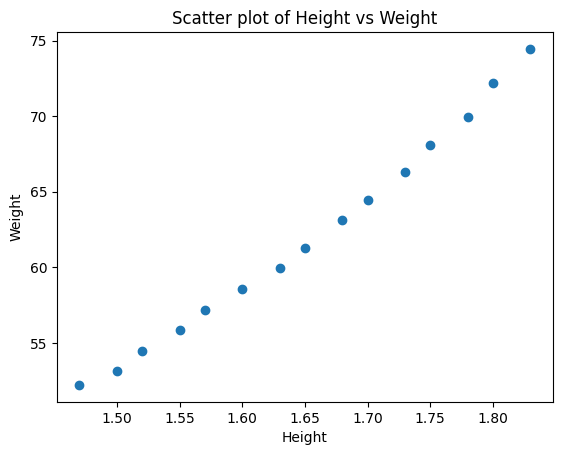

In [4]:
#Scatter plot to visualize the relationship between Height and Weight
plt.scatter(df["Height"], df["Weight"])
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Scatter plot of Height vs Weight")
plt.show()

In [6]:
#Correlation 
df.corr()

,Height,Weight
Height,1.000000,0.994584
Weight,0.994584,1.000000


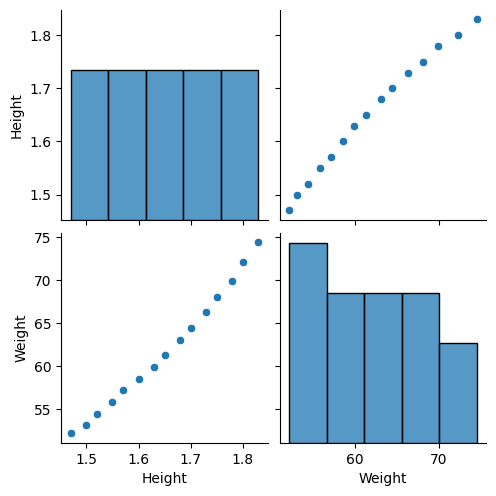

In [7]:
#Seaborn for visualization of the relationship betwen Height and Weight 
sns.pairplot(df)

In [8]:
### Independent and Dependent features 
X = df[['Weight']] ##Independent feature should be dataframe or 2D array 
Y = df['Height'] ## Dependent feature should be series or 1D array


In [9]:
## Train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size= 0.2, random_state= 42)


In [10]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((12, 1), (3, 1), (12,), (3,))

In [11]:
## Standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
X_train , X_test 

(array([[ 1.47062846],
        [-0.53420527],
        [ 0.13407264],
        [-1.13624417],
        [-1.33643315],
        [ 1.80476741],
        [-0.73586622],
        [-0.13382731],
        [ 0.60068959],
        [ 1.1364895 ],
        [-0.9360552 ],
        [-0.33401629]]),
 array([[ 0.33426162],
        [ 0.86858955],
        [-1.47038313]]))

In [14]:
## Applying Linear Regression Model
from sklearn.linear_model import LinearRegression


In [15]:
model = LinearRegression()

In [16]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
print("Coefficient and slope of the line is:", model.coef_)
print("Intercept of the line is:", model.intercept_)


Coefficient and slope of the line is: [0.10660963]
Intercept of the line is: 1.653333333333333


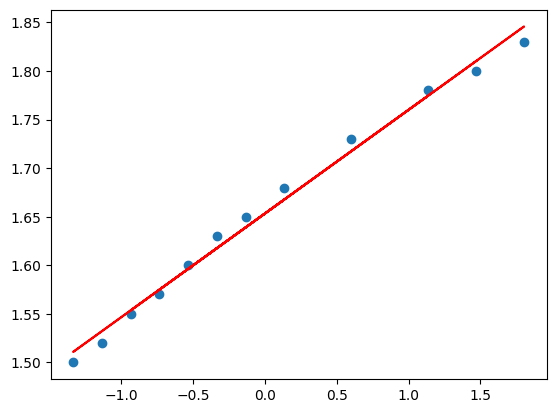

In [24]:
#Plot Training data best fit line 
plt.scatter (X_train , Y_train)
plt.plot(X_train ,model.predict(X_train), color = "red")

In [25]:
#Prediction of the test data 
# 1. Predicted Height Output = intercept +coef_(Weight)
# y_pred_test = regression.intercept- + regression.coef_*X_test
y_pred = model.predict(X_test)


In [27]:
## Performance metrices
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [33]:
mse = mean_squared_error(Y_test ,y_pred)
mae = mean_absolute_error (Y_test ,y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:", mae)
print("Root mean Squared Error:", rmse)

Mean Squared Error: 0.0002815086785527751
Mean Absolute Error: 0.013891386742554449
Root mean Squared Error: 0.01677822036310094


In [34]:
from sklearn.metrics import r2_score
score  = r2_score (Y_test , y_pred)
print ("R2 Score:", score)

R2 Score: 0.9810644386623694


In [ ]:
# Adusted_R2 = 1-[(1-R2)*(n-1)/(n-k-1)]
# where
#  . n = number of samples 
#  . k = number of independent feature 
#  . R2 = r2_score 

In [35]:
#Display adjusted R-squared value
1-(1-score)*(len(Y)-1)/(len(Y)-X.shape[1]-1) 

0.9796078570210132

In [ ]:
##OLs LinearRegression 
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [39]:
import statsmodels.api as sm

In [40]:
model = sm.OLS(Y_train,X_train).fit()

In [41]:
prediction = model.predict(X_test)
print(prediction)

[ 0.03563551  0.09260001 -0.15675699]


In [43]:
print (model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                            0.04573
Date:                Wed, 19 Aug 2026   Prob (F-statistic):                       0.835
Time:                        21:31:50   Log-Likelihood:                         -23.061
No. Observations:                  12   AIC:                                      48.12
Df Residuals:                      11   BIC:                                      48.61
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [42]:
# Prediction for new data 
model.predict(scaler.transform ([[60]]))

array([-0.03451086])

## Key Takeaways

- Linear Regression is a supervised learning algorithm.
- Simple Linear Regression uses one feature.
- Multiple Linear Regression uses multiple features.
- The basic equation is `y = β₀ + β₁x`.
- The model learns coefficients from training data.
- Residuals represent prediction errors.
- MSE is a common squared-error objective.
- Gradient Descent is one method for optimizing model parameters.
- MAE, MSE, RMSE, and R² are common evaluation metrics.
- Train/test separation is important for evaluating generalization.